## Importing all libraries

In [1]:
import unicodedata
import re
import random
import numpy as np
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
SOS_token = 0
EOS_token = 1
PAD_token = 2
MAX_LENGTH = 15

## Data Preprocessing and Vocabulary Building

In [4]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"<PAD>": PAD_token}
        self.word2count = {}
        self.index2word = {SOS_token: "<SOS>", EOS_token: "<EOS>", PAD_token: "<PAD>"}
        self.n_words = 3  

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

def unicodeToAscii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s.strip()

def prepareData(lang1, lang2, sample_size=15000):
    lines = open('/kaggle/input/spa-data/spa.txt', encoding='utf-8').read().strip().split('\n')
    pairs = [[normalizeString(s) for s in l.split('\t')[:2]] for l in lines]
    
    pairs = [p for p in pairs if len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH]
    
    pairs = random.sample(pairs, min(sample_size, len(pairs)))
    
    input_lang = Lang(lang1)
    output_lang = Lang(lang2)
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
        
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'spa', sample_size=15000)


train_pairs, test_val_pairs = train_test_split(pairs, test_size=0.20, random_state=42)
val_pairs, test_pairs = train_test_split(test_val_pairs, test_size=0.50, random_state=42)

print(f"Total pairs: {len(pairs)} | Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)



def create_dataloader(pairs, batch_size=64):
    input_ids = np.zeros((len(pairs), MAX_LENGTH), dtype=np.int32) + PAD_token
    target_ids = np.zeros((len(pairs), MAX_LENGTH), dtype=np.int32) + PAD_token
    
    for idx, (inp, tgt) in enumerate(pairs):
        inp_idx = indexesFromSentence(input_lang, inp) + [EOS_token]
        tgt_idx = indexesFromSentence(output_lang, tgt) + [EOS_token]
        input_ids[idx, :len(inp_idx)] = inp_idx
        target_ids[idx, :len(tgt_idx)] = tgt_idx
        
    dataset = TensorDataset(torch.LongTensor(input_ids), torch.LongTensor(target_ids))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

train_dataloader = create_dataloader(train_pairs)
val_dataloader = create_dataloader(val_pairs)

Total pairs: 15000 | Train: 12000 | Val: 1500 | Test: 1500


## Defining the Models (Encoder & Decoders)

In [5]:
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super(EncoderLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, (hidden, cell)



class DecoderLSTM(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, encoder_outputs):
        
        embedded = self.embedding(x)
        output, hidden = self.lstm(embedded, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden, None 



class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W_q = nn.Linear(hidden_size, hidden_size)
        self.W_k = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.v(torch.tanh(self.W_q(query) + self.W_k(keys)))
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.transpose(1, 2), keys)
        return context, weights

class BahdanauDecoderLSTM(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(BahdanauDecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = BahdanauAttention(hidden_size)
        self.lstm = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, encoder_outputs):
        embedded = self.embedding(x)
        query = hidden[0].transpose(0, 1)
        context, attn_weights = self.attention(query, encoder_outputs)
        
        lstm_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.lstm(lstm_input, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden, attn_weights



class LuongAttention(nn.Module):
    def __init__(self, hidden_size):
        super(LuongAttention, self).__init__()
        self.W = nn.Linear(hidden_size, hidden_size)

    def forward(self, query, keys):
        
        query = self.W(query) 
        scores = torch.bmm(keys, query.transpose(1, 2)) 
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.transpose(1, 2), keys)
        return context, weights

class LuongDecoderLSTM(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(LuongDecoderLSTM, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.attention = LuongAttention(hidden_size)
        self.lstm = nn.LSTM(hidden_size * 2, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden, encoder_outputs):
        embedded = self.embedding(x)
        query = hidden[0].transpose(0, 1)
        context, attn_weights = self.attention(query, encoder_outputs)
        
        lstm_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.lstm(lstm_input, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden, attn_weights

## Training Setup & Loop

In [9]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    total_loss = 0
    teacher_forcing_ratio = 0.5
    
    for input_tensor, target_tensor in dataloader:
        input_tensor, target_tensor = input_tensor.to(device), target_tensor.to(device)
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        decoder_input = torch.tensor([[SOS_token]] * input_tensor.size(0), device=device)
        decoder_hidden = encoder_hidden
        
        batch_loss = 0
        non_pad_elements = 0 
        
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False
        
        for t in range(MAX_LENGTH):
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
            
            step_loss = criterion(decoder_output, target_tensor[:, t])
            batch_loss += step_loss
            non_pad_elements += (target_tensor[:, t] != PAD_token).sum().item()
            
            if use_teacher_forcing:
                decoder_input = target_tensor[:, t].unsqueeze(1) 
            else:
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.detach() 
                
        if non_pad_elements > 0:
            batch_loss = batch_loss / non_pad_elements
        else:
            continue
            
        batch_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
        
        encoder_optimizer.step()
        decoder_optimizer.step()
        total_loss += batch_loss.item()
        
    return total_loss / len(dataloader)

def train_model(encoder, decoder, epochs=15):
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)
    
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token, reduction='sum')
    
    for epoch in range(1, epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print(f"Epoch {epoch}/{epochs} - Loss: {loss:.4f}")
    return encoder, decoder

## Train and Evaluate all 3 Models (BLEU Score calculation)

In [14]:
from nltk.translate.bleu_score import SmoothingFunction 

hidden_size = 256

epochs_to_train = 60

print("--- Training Vanilla Seq2Seq (No Attention) ---")
encoder_vanilla = EncoderLSTM(input_lang.n_words, hidden_size).to(device)
decoder_vanilla = DecoderLSTM(hidden_size, output_lang.n_words).to(device)
train_model(encoder_vanilla, decoder_vanilla, epochs=epochs_to_train)

print("\n--- Training Bahdanau Attention Seq2Seq ---")
encoder_bahdanau = EncoderLSTM(input_lang.n_words, hidden_size).to(device)
decoder_bahdanau = BahdanauDecoderLSTM(hidden_size, output_lang.n_words).to(device)
train_model(encoder_bahdanau, decoder_bahdanau, epochs=epochs_to_train)

print("\n--- Training Luong Attention Seq2Seq ---")
encoder_luong = EncoderLSTM(input_lang.n_words, hidden_size).to(device)
decoder_luong = LuongDecoderLSTM(hidden_size, output_lang.n_words).to(device)
train_model(encoder_luong, decoder_luong, epochs=epochs_to_train)


def evaluate(encoder, decoder, sentence):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        
        decoded_words = []
        decoder_attentions = []
        
        for _ in range(MAX_LENGTH):
            decoder_output, decoder_hidden, decoder_attn = decoder(decoder_input, decoder_hidden, encoder_outputs)
            
            if decoder_attn is not None:
                decoder_attentions.append(decoder_attn.squeeze().cpu().numpy())
                
            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.detach() 
            
        return decoded_words, decoder_attentions

def calculate_bleu(encoder, decoder, test_pairs):
    references = []
    candidates = []
    for eng, spa in test_pairs:
        refs = [spa.split(' ')]
        references.append(refs)
        
        decoded_words, _ = evaluate(encoder, decoder, eng)
        if '<EOS>' in decoded_words:
            decoded_words.remove('<EOS>')
        candidates.append(decoded_words)
        
    
    chencherry = SmoothingFunction()
    score = corpus_bleu(references, candidates, smoothing_function=chencherry.method1)
    return score * 100

print("\n--- BLEU SCORES ---")
print(f"Vanilla No-Attention BLEU: {calculate_bleu(encoder_vanilla, decoder_vanilla, test_pairs):.2f}")
print(f"Bahdanau Attention BLEU:   {calculate_bleu(encoder_bahdanau, decoder_bahdanau, test_pairs):.2f}")
print(f"Luong Attention BLEU:      {calculate_bleu(encoder_luong, decoder_luong, test_pairs):.2f}")

--- Training Vanilla Seq2Seq (No Attention) ---
Epoch 1/60 - Loss: 5.6918
Epoch 2/60 - Loss: 4.9901
Epoch 3/60 - Loss: 4.7010
Epoch 4/60 - Loss: 4.3601
Epoch 5/60 - Loss: 4.1042
Epoch 6/60 - Loss: 3.8728
Epoch 7/60 - Loss: 3.5887
Epoch 8/60 - Loss: 3.3411
Epoch 9/60 - Loss: 3.1981
Epoch 10/60 - Loss: 2.9792
Epoch 11/60 - Loss: 2.8288
Epoch 12/60 - Loss: 2.6628
Epoch 13/60 - Loss: 2.4329
Epoch 14/60 - Loss: 2.2851
Epoch 15/60 - Loss: 2.1851
Epoch 16/60 - Loss: 1.9730
Epoch 17/60 - Loss: 1.8310
Epoch 18/60 - Loss: 1.7314
Epoch 19/60 - Loss: 1.5735
Epoch 20/60 - Loss: 1.4442
Epoch 21/60 - Loss: 1.3211
Epoch 22/60 - Loss: 1.3042
Epoch 23/60 - Loss: 1.1224
Epoch 24/60 - Loss: 1.0836
Epoch 25/60 - Loss: 0.9697
Epoch 26/60 - Loss: 0.8992
Epoch 27/60 - Loss: 0.8086
Epoch 28/60 - Loss: 0.7784
Epoch 29/60 - Loss: 0.6956
Epoch 30/60 - Loss: 0.6487
Epoch 31/60 - Loss: 0.5850
Epoch 32/60 - Loss: 0.5321
Epoch 33/60 - Loss: 0.4861
Epoch 34/60 - Loss: 0.4360
Epoch 35/60 - Loss: 0.3728
Epoch 36/60 - Lo

## Visualizing Attention Weights

Input: the building has exits on all sides .
Target: el edificio tiene salidas por todos lados .
Bahdanau Output: el edificio ha hecho por todo el pais . <EOS>


/tmp/ipykernel_55/2504541046.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
/tmp/ipykernel_55/2504541046.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


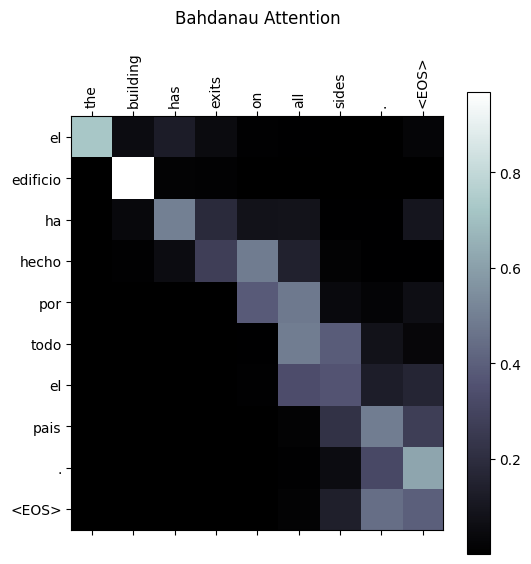

Luong Output: el armazon de estar en la casa . <EOS>


/tmp/ipykernel_55/2504541046.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
/tmp/ipykernel_55/2504541046.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


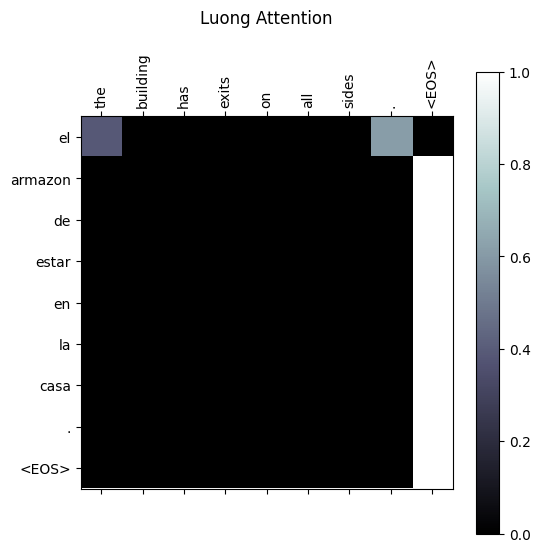

In [15]:
def showAttention(input_sentence, output_words, attentions, title=None):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111)
    
    cax = ax.matshow(np.array(attentions)[:len(output_words), :len(input_sentence.split())+1], cmap='bone')
    fig.colorbar(cax)

    ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    
    if title:
        plt.title(title, pad=20)
    plt.show()

test_sentence = test_pairs[5][0] 
target_sentence = test_pairs[5][1]

print(f"Input: {test_sentence}")
print(f"Target: {target_sentence}")

words_bah, attn_bah = evaluate(encoder_bahdanau, decoder_bahdanau, test_sentence)
print(f"Bahdanau Output: {' '.join(words_bah)}")
showAttention(test_sentence, words_bah, attn_bah, title="Bahdanau Attention")

words_luong, attn_luong = evaluate(encoder_luong, decoder_luong, test_sentence)
print(f"Luong Output: {' '.join(words_luong)}")
showAttention(test_sentence, words_luong, attn_luong, title="Luong Attention")